In [13]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

In [14]:
df = pd.read_csv('../data/sg-tech-jobs-preprocessed-keywords_v2.csv')
df

,python,llm,data,production,ai,sql,cloud,senior,java,javascript,...,competitive,healthcare,consulting,bank_finance,hybrid,location,classifications/0/sub,workTypes/0,salary_lower,salary_upper
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,East,Help Desk & IT Support,Full time,3000.0,3500.0
1,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,Central,Engineering - Network,Full time,6000.0,9000.0
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,East,Help Desk & IT Support,Full time,2800.0,3500.0
3,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,North,Help Desk & IT Support,Full time,4200.0,5200.0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,Central,Networks & Systems Administration,Full time,4000.0,5000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3393,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,Central,Engineering - Software,Full time,8000.0,12000.0
3394,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,Central,Developers/Programmers,Full time,4000.0,6000.0
3395,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,East,Sales - Pre & Post,Full time,4000.0,6000.0
3396,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,Central,Database Development & Administration,Contract/Temp,6000.0,NaN


In [15]:
numeric_features = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] and col not in ['salary_lower', 'salary_upper']]
numeric_features

['python',
 'llm',
 'data',
 'production',
 'ai',
 'sql',
 'cloud',
 'senior',
 'java',
 'javascript',
 'security',
 'git',
 'communication',
 'proficient',
 'competitive',
 'healthcare',
 'consulting',
 'bank_finance',
 'hybrid']

In [16]:
categorical_features = ['location', 'classifications/0/sub', 'workTypes/0']

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

# Salary Lower Bound

In [18]:
X_low = df.drop(['salary_lower', 'salary_upper'], axis=1)
y_low = df['salary_lower']

X_train_low, X_test_low, y_train_low, y_test_low = train_test_split(X_low, y_low, test_size=0.2, random_state=42)

In [19]:
X_train_low

,python,llm,data,production,ai,sql,cloud,senior,java,javascript,...,communication,proficient,competitive,healthcare,consulting,bank_finance,hybrid,location,classifications/0/sub,workTypes/0
2155,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,Central,Programme & Project Management,Contract/Temp
2959,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,Central,Programme & Project Management,Full time
3237,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,Central,Management,Full time
3121,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,North,Developers/Programmers,Full time
1746,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,Central,Developers/Programmers,Full time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,Unknown,Security,Full time
1130,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,Central,Engineering - Software,Full time
1294,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,Central,Management,Full time
860,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,East,Engineering - Software,Full time


In [20]:
y_train_low

2155     4000.0
2959     5000.0
3237      800.0
3121     4700.0
1746    10000.0
         ...   
1095     5500.0
1130     8000.0
1294     9000.0
860      6000.0
3174     5500.0
Name: salary_lower, Length: 2718, dtype: float64

In [21]:
lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42))
])

lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor(random_state=42))
])

cb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', CatBoostRegressor(random_state=42, verbose=0))
])

In [22]:
lr.fit(X_train_low, y_train_low)
y_pred_low_lr = lr.predict(X_test_low)
mse_lr = mean_squared_error(y_test_low, y_pred_low_lr)
mae_lr = mean_absolute_error(y_test_low, y_pred_low_lr)
r2_lr = r2_score(y_test_low, y_pred_low_lr)

rf.fit(X_train_low, y_train_low)
y_pred_low_rf = rf.predict(X_test_low)
mse_rf = mean_squared_error(y_test_low, y_pred_low_rf)
mae_rf = mean_absolute_error(y_test_low, y_pred_low_rf)
r2_rf = r2_score(y_test_low, y_pred_low_rf)

xgb.fit(X_train_low, y_train_low)
y_pred_low_xgb = xgb.predict(X_test_low)
mse_xgb = mean_squared_error(y_test_low, y_pred_low_xgb)
mae_xgb = mean_absolute_error(y_test_low, y_pred_low_xgb)
r2_xgb = r2_score(y_test_low, y_pred_low_xgb)

lgbm.fit(X_train_low, y_train_low)
y_pred_low_lgbm = lgbm.predict(X_test_low)
mse_lgbm = mean_squared_error(y_test_low, y_pred_low_lgbm)
mae_lgbm = mean_absolute_error(y_test_low, y_pred_low_lgbm)
r2_lgbm = r2_score(y_test_low, y_pred_low_lgbm)

cb.fit(X_train_low, y_train_low)
y_pred_low_cb = cb.predict(X_test_low)
mse_cb = mean_squared_error(y_test_low, y_pred_low_cb)
mae_cb = mean_absolute_error(y_test_low, y_pred_low_cb)
r2_cb = r2_score(y_test_low, y_pred_low_cb)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000293 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 78
[LightGBM] [Info] Number of data points in the train set: 2718, number of used features: 39
[LightGBM] [Info] Start training from score 4813.429360


c:\Users\Dody Harianto\Documents\Personal Projects\ML Projects\SG Tech Jobs Salary Predictor\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [23]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost'],
    'MSE': [mse_lr, mse_rf, mse_xgb, mse_lgbm, mse_cb],
    'MAE': [mae_lr, mae_rf, mae_xgb, mae_lgbm, mae_cb],
    'R2 Score': [r2_lr, r2_rf, r2_xgb, r2_lgbm, r2_cb]
}).sort_values(by='MAE')

results

,Model,MSE,MAE,R2 Score
2,XGBoost,1.422534e+07,1323.829304,0.209298
1,Random Forest,1.450862e+07,1331.414815,0.193553
4,CatBoost,1.432624e+07,1413.519403,0.203690
3,LightGBM,1.516497e+07,1592.641805,0.157070
0,Linear Regression,1.587790e+07,1679.660100,0.117443


C:\Users\Dody Harianto\AppData\Local\Temp\ipykernel_16948\1388247514.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MAE', y='Model', data=results, palette='Set2')


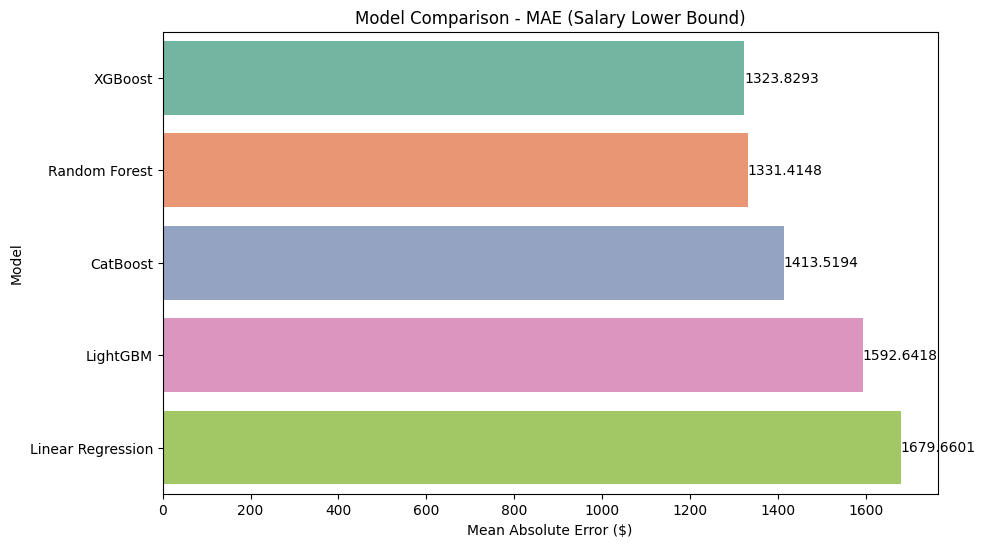

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(x='MAE', y='Model', data=results, palette='Set2')
for bar in plt.gca().patches:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height() / 2, f'{width:.4f}', va='center')
plt.title('Model Comparison - MAE (Salary Lower Bound)')
plt.xlabel('Mean Absolute Error ($)')
plt.show()

In [25]:
joblib.dump(xgb, '../models/xgb_baseline_v2.pkl')

['../models/xgb_baseline_v2.pkl']